# Exploratory Data Analysis: Financial Health Index
Comprehensive analysis of business financial health data from Southern Africa.

**Target:** Predict financial health (Low/Medium/High) for SMEs
**Data:** 9,618 training records × 39 features across 4 countries

## 1.1 Setup & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Load data
train = pd.read_csv('../data/Train.csv')
test = pd.read_csv('../data/Test.csv')
var_defs = pd.read_csv('../data/VariableDefinitions.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nData types:\n{train.dtypes}")
print(f"\nFirst 5 rows:")
train.head()

Train shape: (9618, 39)
Test shape: (2405, 38)

Data types:
ID                                                                      str
country                                                                 str
owner_age                                                           float64
attitude_stable_business_environment                                    str
attitude_worried_shutdown                                               str
compliance_income_tax                                                   str
perception_insurance_doesnt_cover_losses                                str
perception_cannot_afford_insurance                                      str
personal_income                                                     float64
business_expenses                                                   float64
business_turnover                                                   float64
business_age_years                                                  float64
motor_vehicle_insurance     

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


## 1.2 Target Distribution

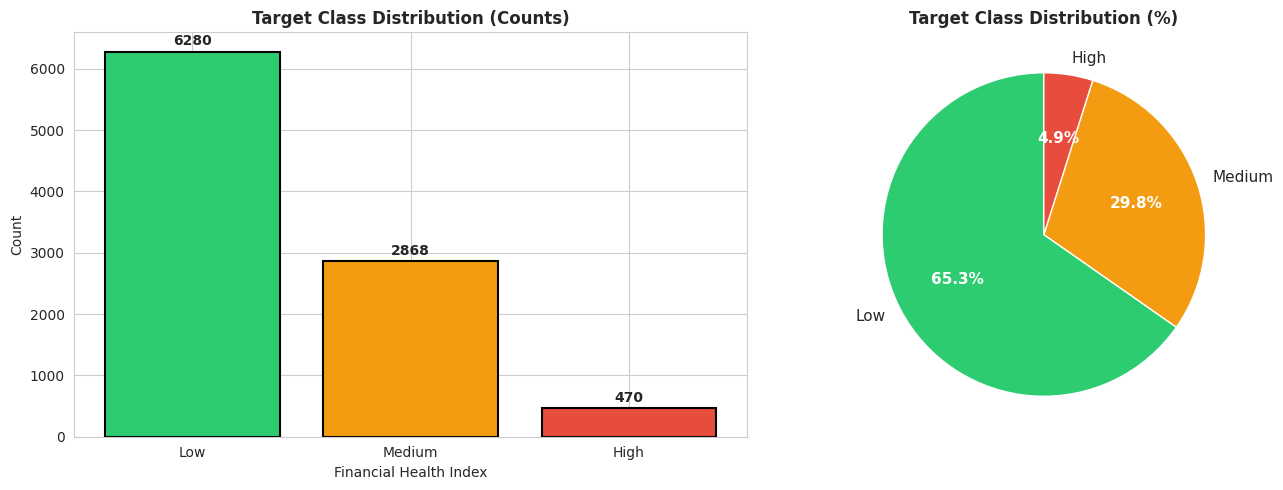


Target distribution:
Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64

Class proportions:
Target
Low       65.294240
Medium    29.819089
High       4.886671
Name: proportion, dtype: float64

Note: SEVERE CLASS IMBALANCE - High class is only 4.9% of data


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = train['Target'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Target Class Distribution (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Financial Health Index')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart with percentages
target_pct = train['Target'].value_counts(normalize=True) * 100
wedges, texts, autotexts = axes[1].pie(
    target_pct.values, labels=target_pct.index, colors=colors,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[1].set_title('Target Class Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTarget distribution:")
print(f"{target_counts}")
print(f"\nClass proportions:")
print(f"{target_pct}")
print(f"\nNote: SEVERE CLASS IMBALANCE - High class is only {target_pct['High']:.1f}% of data")

## 1.3 Univariate Analysis — Numeric Features

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('ID') if 'ID' in numeric_cols else None

print(f"Numeric features: {numeric_cols}")
print(f"\nNumeric feature statistics:")
train[numeric_cols].describe()

Numeric features: ['owner_age', 'personal_income', 'business_expenses', 'business_turnover', 'business_age_years', 'business_age_months']

Numeric feature statistics:


,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months
count,9618.000000,9.509000e+03,9.389000e+03,9.402000e+03,9366.000000,5507.000000
mean,41.705344,2.627345e+05,4.583838e+05,1.348210e+06,7.030536,3.636281
std,13.314010,2.566268e+06,6.184746e+06,8.804741e+06,7.650349,3.386488
min,18.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,32.000000,3.000000e+02,7.000000e+02,1.500000e+03,2.000000,0.000000
50%,40.000000,2.000000e+03,3.000000e+03,6.000000e+03,4.000000,3.000000
75%,50.000000,2.500000e+04,2.500000e+04,5.000000e+04,10.000000,6.000000
max,103.000000,1.500000e+08,5.000000e+08,4.200000e+08,60.000000,11.000000


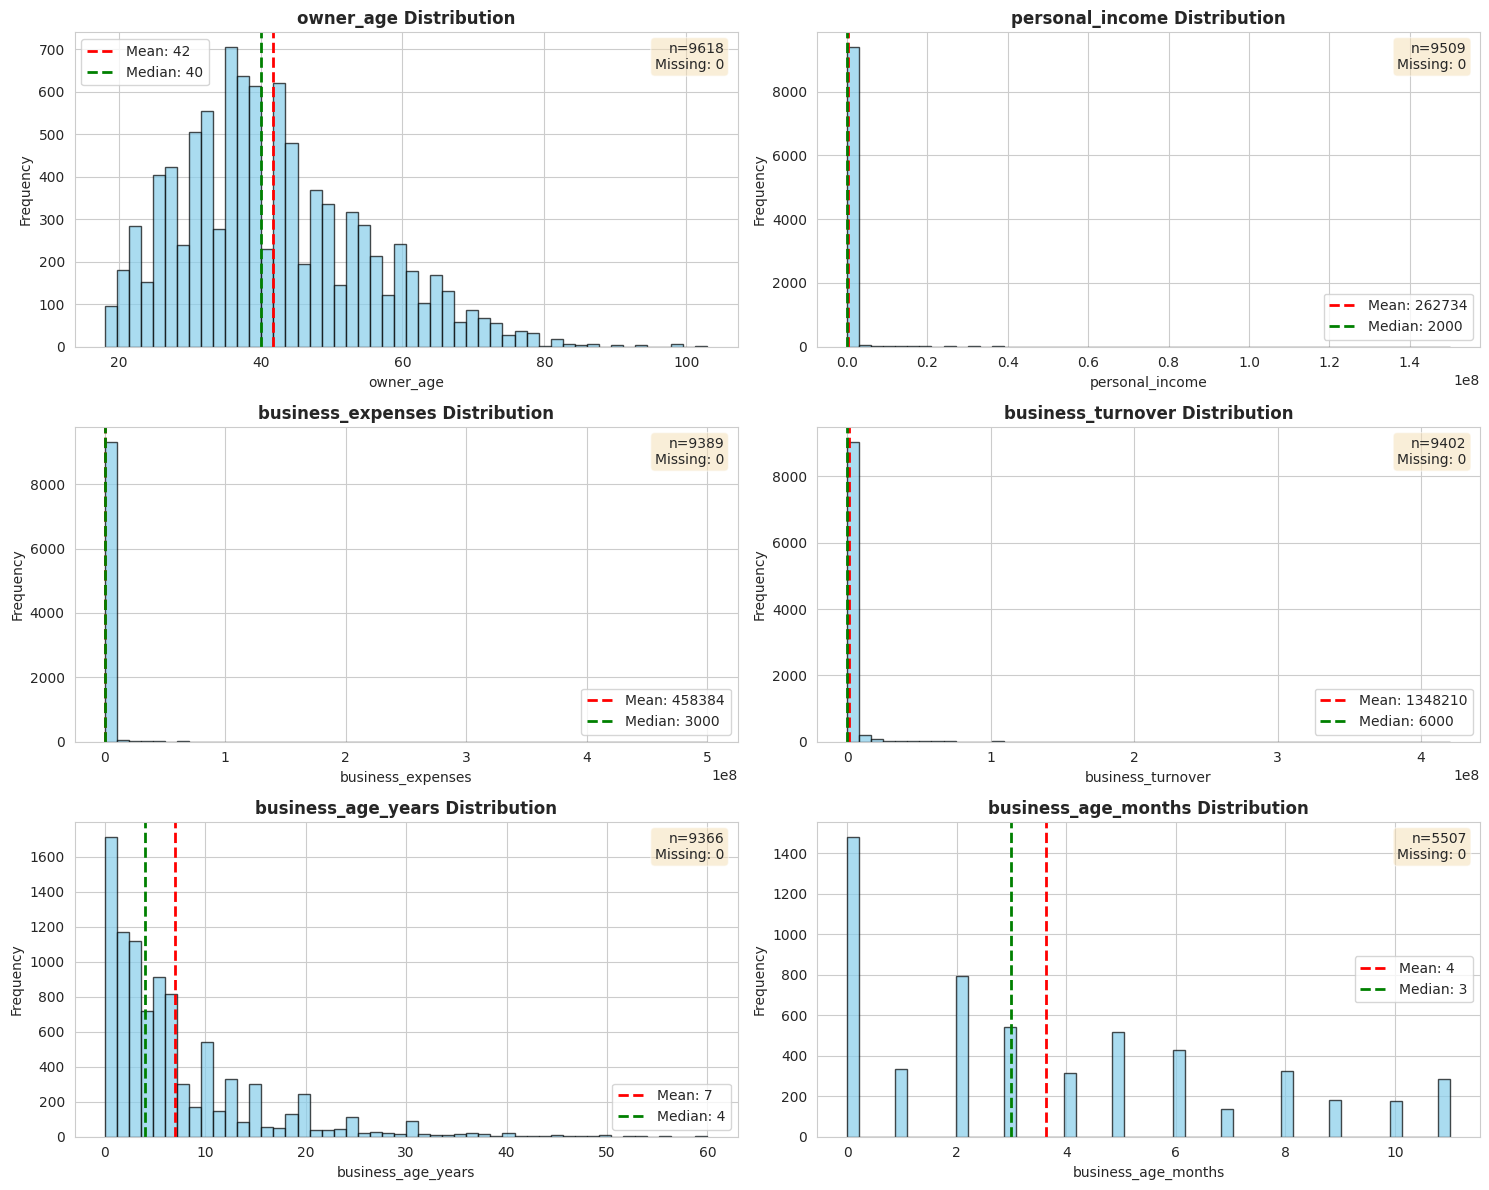


Key findings:
- personal_income: mean=262734, median=2000
  Extreme right skew (max=150000000)
- business_expenses: mean=458384, median=3000
  Extreme right skew (max=500000000)
- business_turnover: mean=1348210, median=6000
  Extreme right skew (max=420000000)


In [4]:
# Histograms with KDE for numeric features
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

financial_cols = ['owner_age', 'personal_income', 'business_expenses', 
                   'business_turnover', 'business_age_years', 'business_age_months']

for idx, col in enumerate(financial_cols):
    if col in train.columns:
        data = train[col].dropna()
        axes[idx].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col} Distribution', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.0f}')
        axes[idx].axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.0f}')
        axes[idx].legend()
        axes[idx].text(0.98, 0.97, f'n={len(data)}\nMissing: {data.isna().sum()}',
                      transform=axes[idx].transAxes, ha='right', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nKey findings:")
print(f"- personal_income: mean={train['personal_income'].mean():.0f}, median={train['personal_income'].median():.0f}")
print(f"  Extreme right skew (max={train['personal_income'].max():.0f})")
print(f"- business_expenses: mean={train['business_expenses'].mean():.0f}, median={train['business_expenses'].median():.0f}")
print(f"  Extreme right skew (max={train['business_expenses'].max():.0f})")
print(f"- business_turnover: mean={train['business_turnover'].mean():.0f}, median={train['business_turnover'].median():.0f}")
print(f"  Extreme right skew (max={train['business_turnover'].max():.0f})")

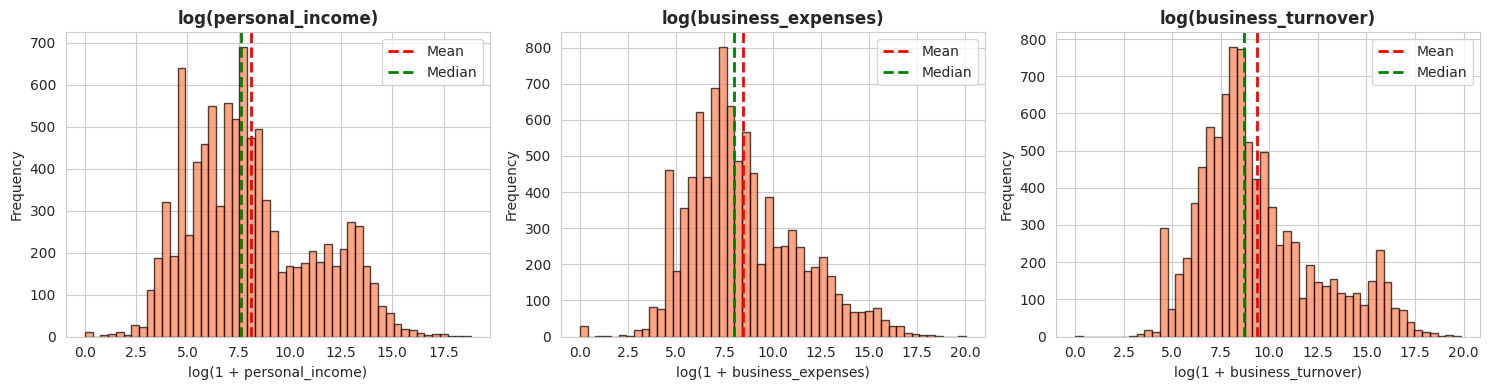

Log transforms much more normal-like → use log(x+1) in modeling


In [5]:
# Log-scale plots for financial features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, col in enumerate(['personal_income', 'business_expenses', 'business_turnover']):
    data = train[col].dropna()
    data_log = np.log1p(data)  # log(x+1) to handle zeros
    
    axes[idx].hist(data_log, bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'log({col})', fontweight='bold')
    axes[idx].set_xlabel(f'log(1 + {col})')
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(data_log.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean')
    axes[idx].axvline(data_log.median(), color='green', linestyle='--', linewidth=2, label=f'Median')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("Log transforms much more normal-like → use log(x+1) in modeling")

## 1.4 Univariate Analysis — Categorical Features

In [6]:
# Missing data overview
missing_pct = (train.isnull().sum() / len(train)) * 100
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing_Count': train.isnull().sum().values,
    'Missing_Percent': missing_pct.values
}).sort_values('Missing_Percent', ascending=False)

print("Top 15 columns with missing data:")
print(missing_df.head(15))

Top 15 columns with missing data:
                                Column  Missing_Count  Missing_Percent
37                uses_informal_lender           4489        46.672905
36         uses_friends_family_savings           4488        46.662508
35          motivation_make_more_money           4291        44.614265
34                   funeral_insurance           4188        43.543356
33                   medical_insurance           4188        43.543356
32                 business_age_months           4111        42.742774
31             future_risk_theft_stock           4100        42.628405
30                      has_debit_card           4003        41.619879
29                has_internet_banking           4003        41.619879
28                    has_loan_account           3999        41.578291
14           current_problem_cash_flow           3778        39.280516
27             marketing_word_of_mouth           3695        38.417550
26              problem_sourcing_money     

## 1.5 Missing Data Analysis

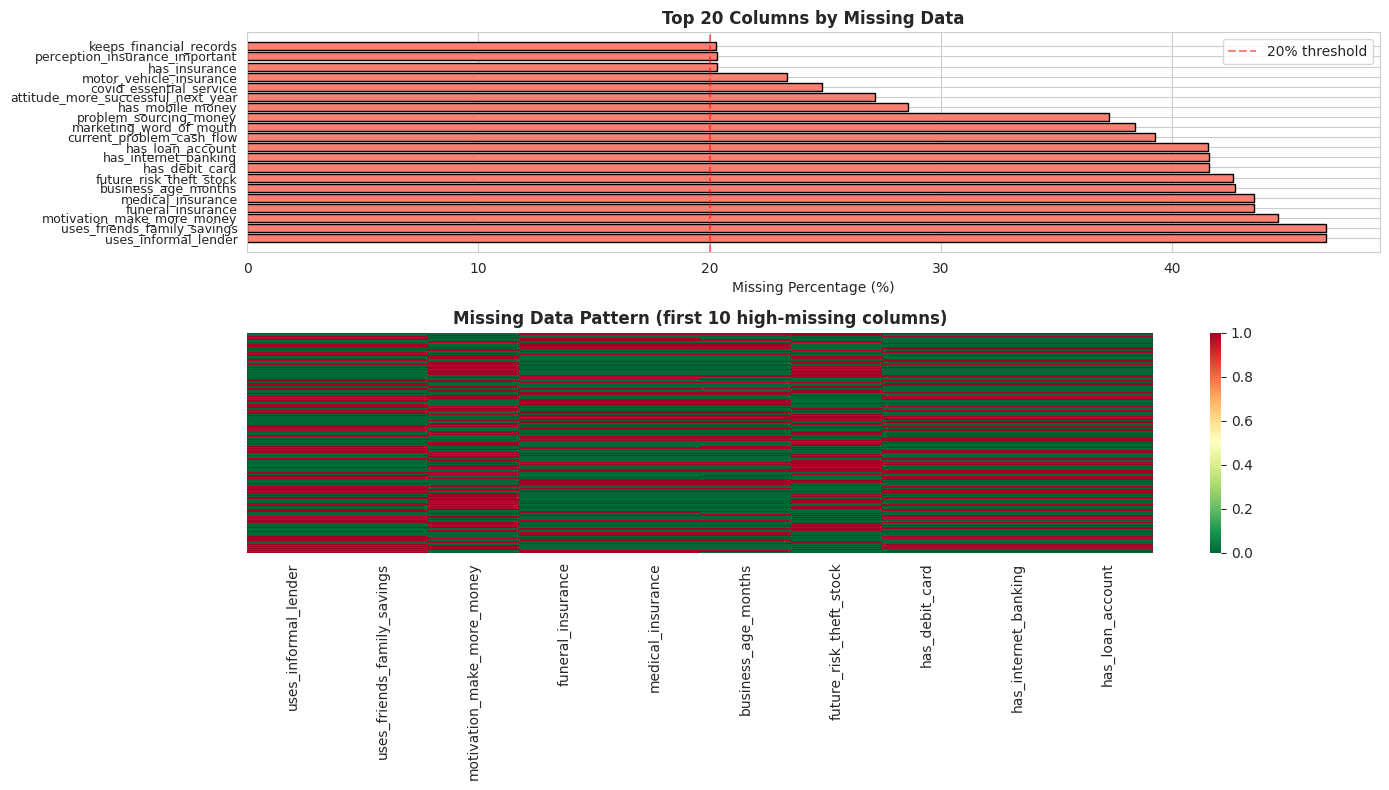


Key finding: 20 columns with >20% missing data
Cannot drop rows; will use imputation + missing indicators


In [7]:
# Heatmap of missing values (sample)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Bar chart: % missing per column
top_missing = missing_df.head(20)
axes[0].barh(range(len(top_missing)), top_missing['Missing_Percent'], color='salmon', edgecolor='black')
axes[0].set_yticks(range(len(top_missing)))
axes[0].set_yticklabels(top_missing['Column'], fontsize=9)
axes[0].set_xlabel('Missing Percentage (%)')
axes[0].set_title('Top 20 Columns by Missing Data', fontweight='bold')
axes[0].axvline(20, color='red', linestyle='--', alpha=0.5, label='20% threshold')
axes[0].legend()

# Heatmap of missing values for high-missing columns
high_missing_cols = missing_df[missing_df['Missing_Percent'] > 10]['Column'].head(15).tolist()
if high_missing_cols:
    sns.heatmap(train[high_missing_cols[:10]].isnull(), cbar=True, cmap='RdYlGn_r', ax=axes[1], yticklabels=False)
    axes[1].set_title('Missing Data Pattern (first 10 high-missing columns)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey finding: 20 columns with >20% missing data")
print(f"Cannot drop rows; will use imputation + missing indicators")

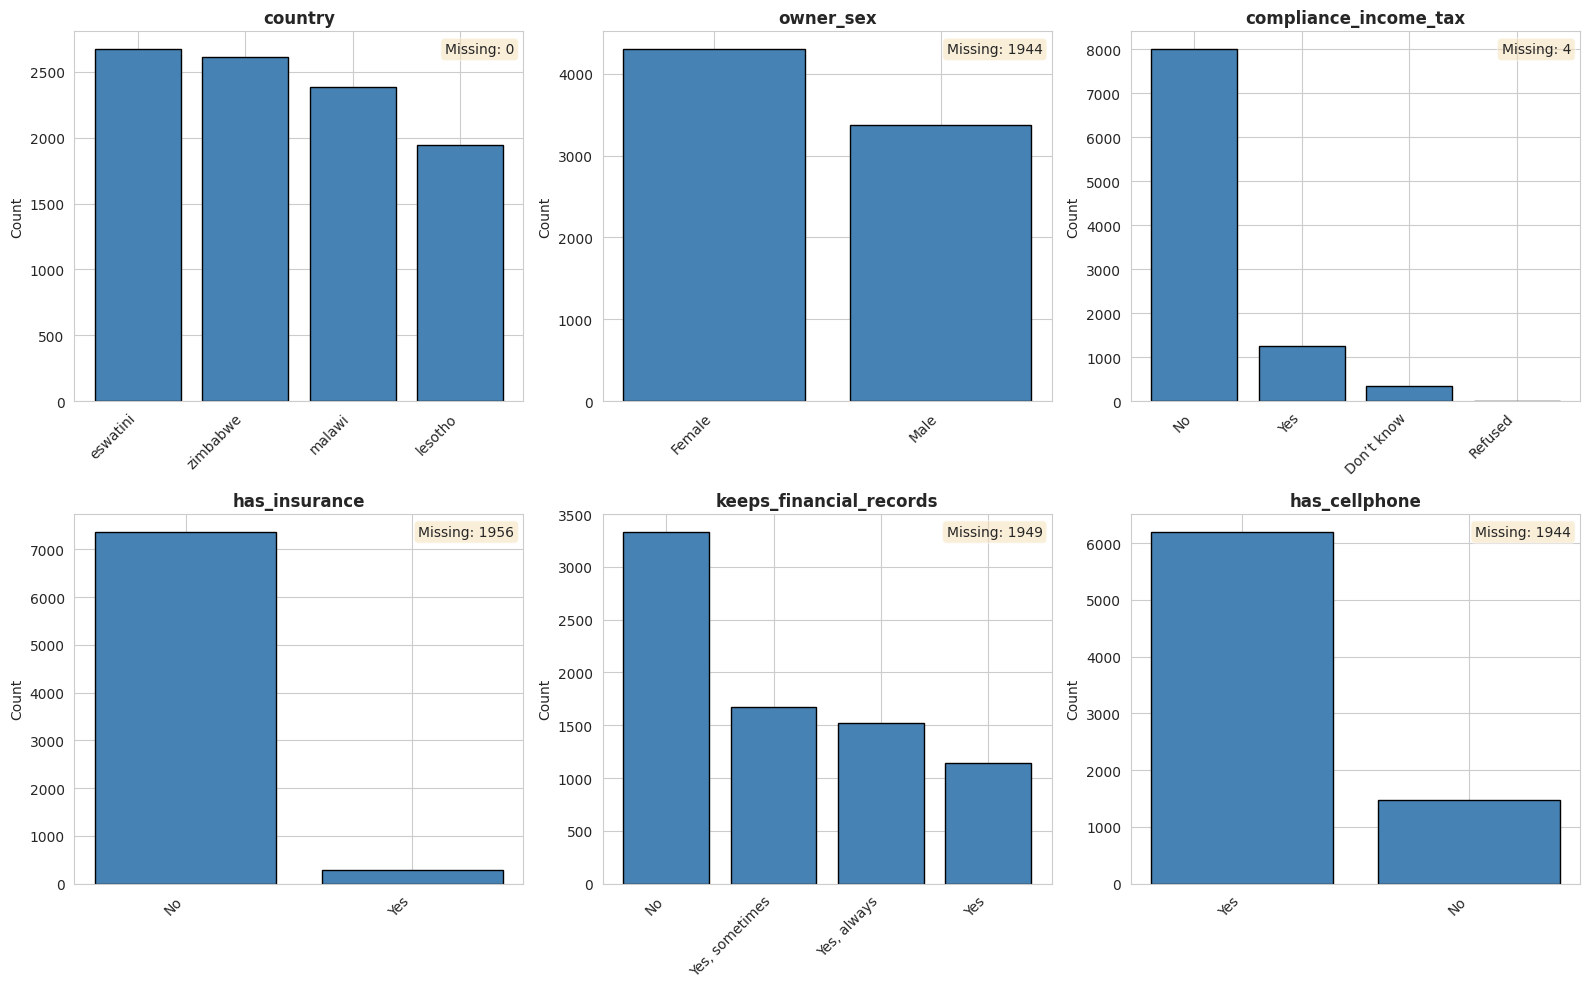


Categorical feature summary:

country:
country
eswatini    2674
zimbabwe    2612
malawi      2388
lesotho     1944
Name: count, dtype: int64

owner_sex:
owner_sex
Female    4303
Male      3371
Name: count, dtype: int64

compliance_income_tax:
compliance_income_tax
No            8010
Yes           1252
Don’t know     341
Refused         11
Name: count, dtype: int64

has_insurance:
has_insurance
No     7375
Yes     287
Name: count, dtype: int64

keeps_financial_records:
keeps_financial_records
No                3334
Yes, sometimes    1671
Yes, always       1525
Yes               1139
Name: count, dtype: int64

has_cellphone:
has_cellphone
Yes    6203
No     1471
Name: count, dtype: int64


In [8]:
# Top categorical features
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'ID']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

top_cat_features = ['country', 'owner_sex', 'compliance_income_tax', 
                     'has_insurance', 'keeps_financial_records', 'has_cellphone']

for idx, col in enumerate(top_cat_features):
    if col in train.columns:
        data = train[col].value_counts()
        axes[idx].bar(range(len(data)), data.values, color='steelblue', edgecolor='black')
        axes[idx].set_xticks(range(len(data)))
        axes[idx].set_xticklabels(data.index, rotation=45, ha='right')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Count')
        axes[idx].text(0.98, 0.97, f'Missing: {train[col].isna().sum()}',
                      transform=axes[idx].transAxes, ha='right', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nCategorical feature summary:")
for col in top_cat_features:
    if col in train.columns:
        print(f"\n{col}:")
        print(train[col].value_counts())

## 1.6 Bivariate Analysis — Numeric Features vs Target

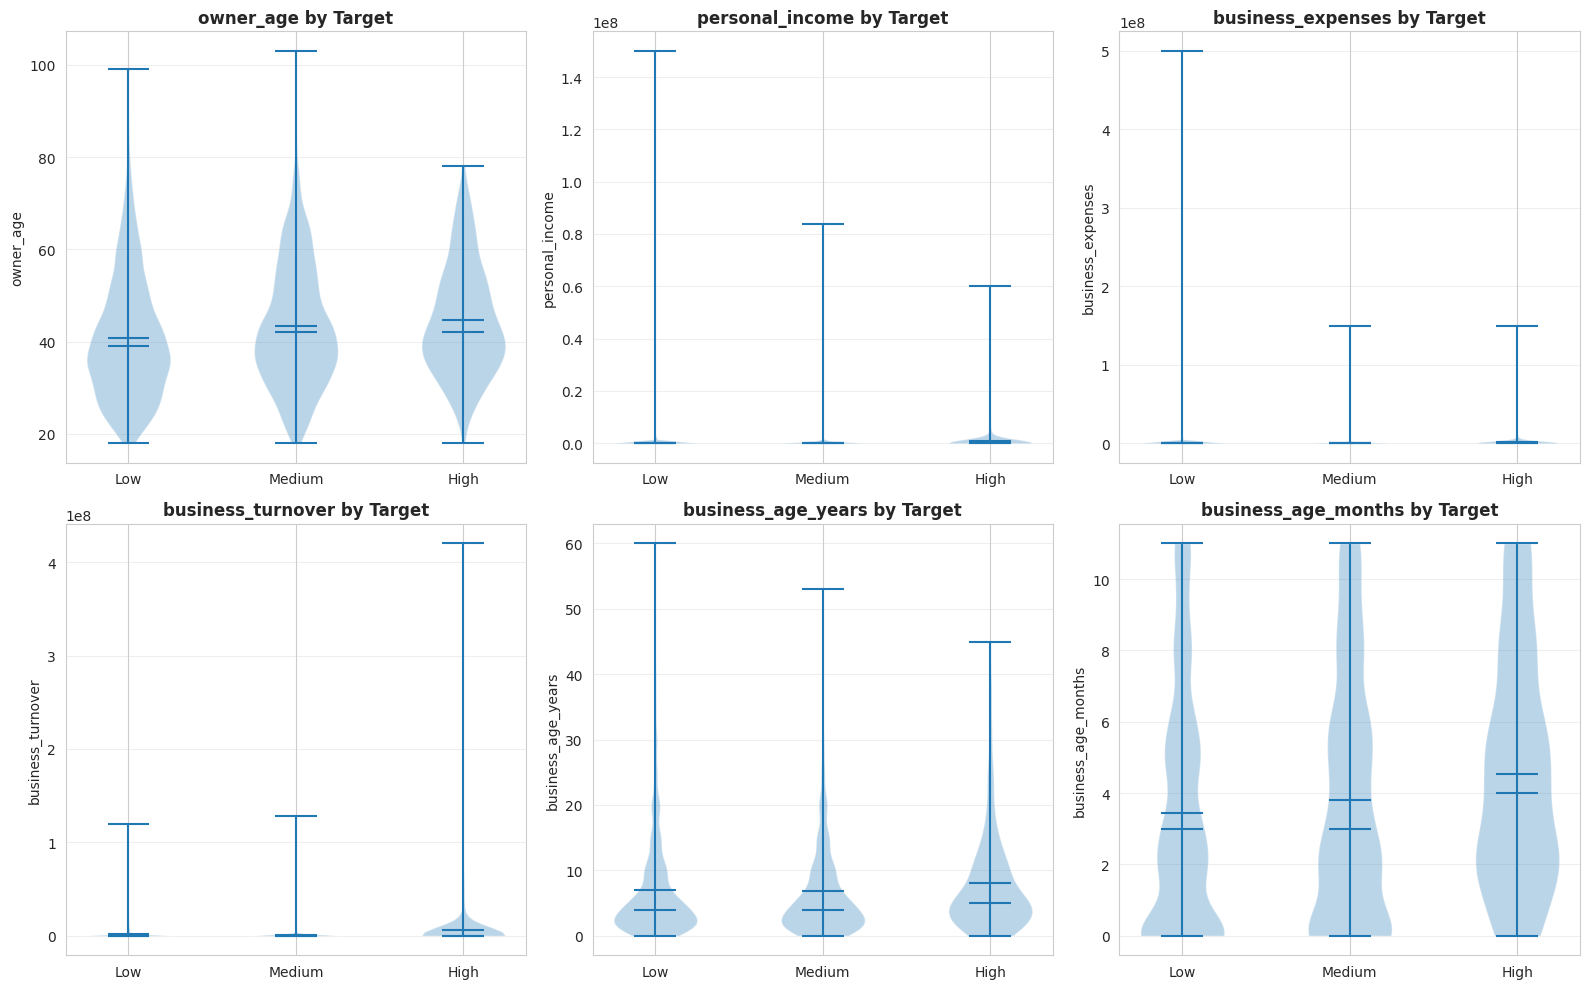


Bivariate numeric insights:

owner_age by Target:
         mean   50%
Target             
High    44.61  42.0
Low     40.73  39.0
Medium  43.36  42.0

personal_income by Target:
             mean     50%
Target                   
High    882802.24  5000.0
Low     254094.82  2000.0
Medium  180199.97  1500.0

business_expenses by Target:
              mean      50%
Target                     
High    1062800.57  10100.0
Low      485568.60   3000.0
Medium   297952.64   2000.0

business_turnover by Target:
              mean      50%
Target                     
High    5598924.41  45000.0
Low     1253353.39   6000.0
Medium   852437.07   4500.0

business_age_years by Target:
        mean  50%
Target           
High    8.02  5.0
Low     7.03  4.0
Medium  6.86  4.0

business_age_months by Target:
        mean  50%
Target           
High    4.54  4.0
Low     3.44  3.0
Medium  3.82  3.0


In [9]:
# Violin plots: numeric features by target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

numeric_features = ['owner_age', 'personal_income', 'business_expenses', 
                     'business_turnover', 'business_age_years', 'business_age_months']

target_order = ['Low', 'Medium', 'High']
colors_target = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for idx, col in enumerate(numeric_features):
    if col in train.columns:
        # Create violin plot
        parts = axes[idx].violinplot(
            [train[train['Target'] == t][col].dropna().values for t in target_order],
            positions=range(len(target_order)), showmeans=True, showmedians=True
        )
        axes[idx].set_xticks(range(len(target_order)))
        axes[idx].set_xticklabels(target_order)
        axes[idx].set_title(f'{col} by Target', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nBivariate numeric insights:")
for col in numeric_features:
    if col in train.columns:
        print(f"\n{col} by Target:")
        print(train.groupby('Target')[col].describe()[['mean', '50%']].round(2))

## 1.7 Bivariate Analysis — Categorical Features vs Target

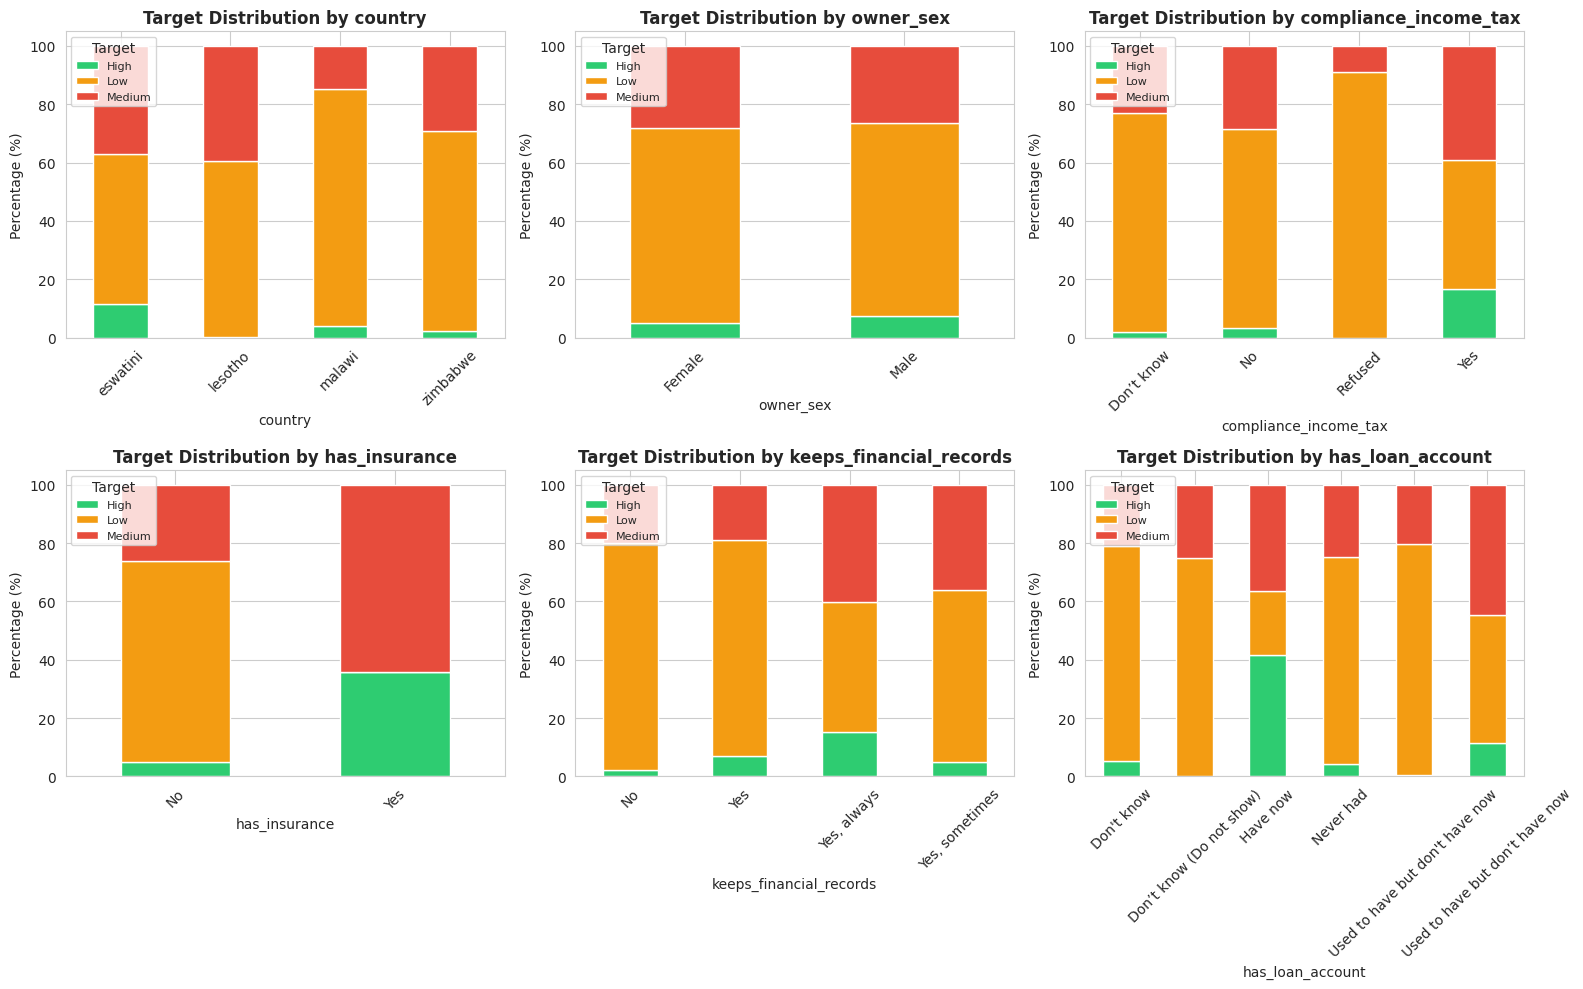


Chi-square test: categorical features vs target
country: chi2=831.70, p-value=0.0000
owner_sex: chi2=211.65, p-value=0.0000
compliance_income_tax: chi2=570.81, p-value=0.0000
has_insurance: chi2=1063.33, p-value=0.0000
keeps_financial_records: chi2=990.68, p-value=0.0000
has_loan_account: chi2=1611.08, p-value=0.0000


In [10]:
# Stacked bar charts: categorical features by target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_features_to_plot = ['country', 'owner_sex', 'compliance_income_tax',
                         'has_insurance', 'keeps_financial_records', 'has_loan_account']

for idx, col in enumerate(cat_features_to_plot):
    if col in train.columns:
        # Create crosstab
        ct = pd.crosstab(train[col], train['Target'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[idx], color=['#2ecc71', '#f39c12', '#e74c3c'])
        axes[idx].set_title(f'Target Distribution by {col}', fontweight='bold')
        axes[idx].set_ylabel('Percentage (%)')
        axes[idx].set_xlabel(col)
        axes[idx].legend(title='Target', loc='upper left', fontsize=8)
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nChi-square test: categorical features vs target")
for col in cat_features_to_plot:
    if col in train.columns:
        ct = pd.crosstab(train[col].fillna('Missing'), train['Target'])
        chi2, p_val, dof, expected = chi2_contingency(ct)
        print(f"{col}: chi2={chi2:.2f}, p-value={p_val:.4f}")

## 1.8 Correlation & Feature Importance Preview


Correlation with Target (numeric features):
               Feature  Correlation_with_Target
0            owner_age                 0.100535
5  business_age_months                 0.085885
3    business_turnover                 0.053038
1      personal_income                 0.024107
4   business_age_years                 0.010519
2    business_expenses                 0.003366


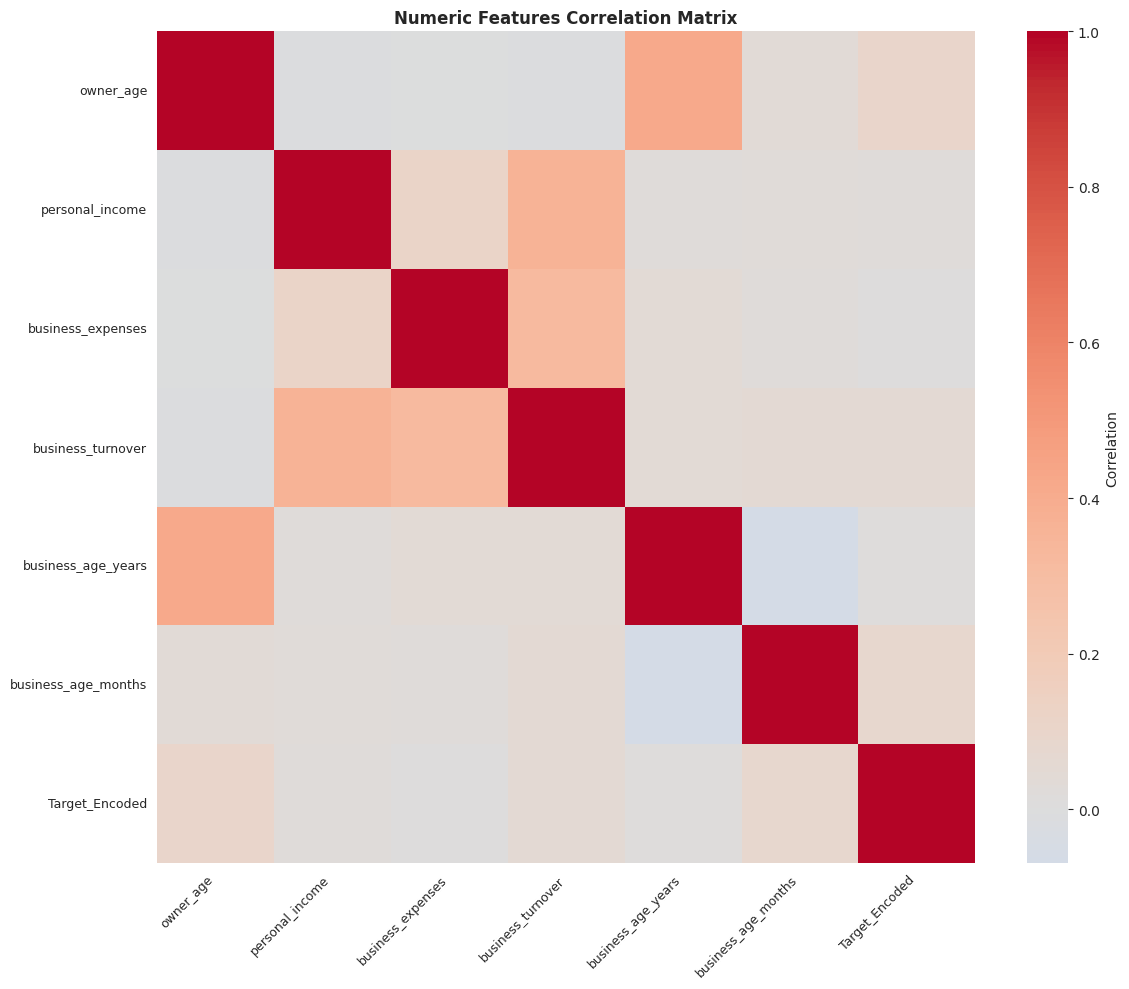

In [11]:
# Numeric correlation with target
numeric_cols_all = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_all = [c for c in numeric_cols_all if c != 'ID']

# Encode target for correlation
target_encoded = train['Target'].map({'Low': 0, 'Medium': 1, 'High': 2})

correlations = pd.DataFrame({
    'Feature': numeric_cols_all,
    'Correlation_with_Target': [train[col].corr(target_encoded) for col in numeric_cols_all]
}).sort_values('Correlation_with_Target', key=abs, ascending=False)

print("\nCorrelation with Target (numeric features):")
print(correlations)

# Heatmap of numeric correlations
fig, ax = plt.subplots(figsize=(12, 10))
numeric_with_target = numeric_cols_all + ['Target_Encoded']
temp_df = train[numeric_cols_all].copy()
temp_df['Target_Encoded'] = target_encoded

corr_matrix = temp_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Numeric Features Correlation Matrix', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Summary statistics
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset Size:")
print(f"  - Training: {train.shape[0]:,} records × {train.shape[1]} features")
print(f"  - Test: {test.shape[0]:,} records × {test.shape[1]} features")

print(f"\nTarget Distribution:")
print(f"  - Low:    {(train['Target'] == 'Low').sum():5d} ({(train['Target'] == 'Low').sum()/len(train)*100:5.1f}%)")
print(f"  - Medium: {(train['Target'] == 'Medium').sum():5d} ({(train['Target'] == 'Medium').sum()/len(train)*100:5.1f}%)")
print(f"  - High:   {(train['Target'] == 'High').sum():5d} ({(train['Target'] == 'High').sum()/len(train)*100:5.1f}%) ← MINORITY CLASS")

print(f"\nKey Data Characteristics:")
print(f"  - Numeric features: 6 (owner_age, personal_income, business_expenses, etc)")
print(f"  - Categorical features: 32")
print(f"  - Missing data: {missing_pct.max():.1f}% max in single column")
print(f"  - 20+ columns with >20% missing → need smart imputation")
print(f"  - Extreme right skew in financial features → log transform essential")
print(f"  - 3-tier categorical patterns (Never had/Used to have/Have now)")

print(f"\nRecommendations for Modeling:")
print(f"  1. Use class_weight='balanced' for severe imbalance (High=5%)")
print(f"  2. Use StratifiedKFold(5) for cross-validation")
print(f"  3. Log-transform personal_income, business_expenses, business_turnover")
print(f"  4. Ordinal encode 3-tier ownership features (0→1→2)")
print(f"  5. Use median imputation for numeric, mode for categorical")
print(f"  6. Add missing data indicators for high-missing columns")
print(f"  7. Feature engineering: ratios, combined_age, product counts")
print(f"  8. Primary metric: weighted F1 score (handles imbalance)")


EXPLORATORY DATA ANALYSIS SUMMARY

Dataset Size:
  - Training: 9,618 records × 39 features
  - Test: 2,405 records × 38 features

Target Distribution:
  - Low:     6280 ( 65.3%)
  - Medium:  2868 ( 29.8%)
  - High:     470 (  4.9%) ← MINORITY CLASS

Key Data Characteristics:
  - Numeric features: 6 (owner_age, personal_income, business_expenses, etc)
  - Categorical features: 32
  - Missing data: 46.7% max in single column
  - 20+ columns with >20% missing → need smart imputation
  - Extreme right skew in financial features → log transform essential
  - 3-tier categorical patterns (Never had/Used to have/Have now)

Recommendations for Modeling:
  1. Use class_weight='balanced' for severe imbalance (High=5%)
  2. Use StratifiedKFold(5) for cross-validation
  3. Log-transform personal_income, business_expenses, business_turnover
  4. Ordinal encode 3-tier ownership features (0→1→2)
  5. Use median imputation for numeric, mode for categorical
  6. Add missing data indicators for high-mis